# MIS780 Advanced AI For Business - Assessment 2 - T2 2025

## Task 3 - Forecasting Air Quality (PM2.5) for Beijing using Time Series Deep Learning Models

**Student Name:** Nishant Jawa

**Student ID:** s224285165

## Table of Content

1. [Executive Summary](#cell_Summary)

2. [Data Preprocessing](#cell_Preprocessing)

3. [Predictive Modeling](#cell_model)

4. [Experiments Report](#cell_report)

5. [Role of GenAI](#cell_GenAI)



<a id = "cell_Summary"></a>
## 1. Executive Summary

The business problem addressed in Task 3 was forecasting hourly PM2.5 concentrations in Beijing to support proactive public health measures and environmental policy. The dataset comprised hourly measurements from 2013–2016 of pollutants (PM2.5, SO₂, NO₂, CO, O₃) and meteorological indicators (temperature, pressure, dew point, wind speed). Preprocessing steps included converting datetime indices, interpolating missing values (notably NO₂ and O₃), scaling features, and splitting data into a training set (2013–2015) and a test set (January 2016).

###**Key Steps**
- **Modelling Flow:** We followed a structured progression starting with baseline models (SimpleRNN, LSTM, GRU), then experimenting with lighter configurations (fewer units), stacked architectures, and finally advanced two-layer models with dropout and recurrent dropout for improved generalisation.
Evaluation Metrics: Model performance was assessed using RMSE, MAE, and R². Horizon-wise MAE showed that models were most accurate in predicting short-term horizons (1–6 hours ahead) and less reliable for long-term horizons (+12 to +24 hours), which is typical in time-series forecasting.

- **Results:** The strongest model was the 2-layer LSTM (128→64 with dropout), achieving RMSE ≈ 44.2, MAE ≈ 33.1, and R² ≈ 0.33. This outperformed all baselines SimpleRNN (best single-layer baseline with RMSE ≈ 50.9) and GRU by effectively capturing both short- and long-term dependencies while controlling overfitting.

**Conclusion:** Deep learning approaches, particularly stacked LSTM architectures with dropout, provide reliable 24-hour PM2.5 forecasts. While accuracy decreases over longer horizons, such models are practical for short-term early warnings in air quality monitoring systems. For real-world deployment, they should be supported by continuous data quality checks, retraining on updated datasets, and integration into decision-support platforms for policymakers and citizens.

<a id = "cell_Preprocessing"></a>
## 2. Data Preprocessing

In [ ]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import SGD
from tensorflow.random import set_seed

set_seed(2701)
np.random.seed(2701)

In [ ]:
!pip install gdown --quiet

import gdown
import pandas as pd

# Google Drive file ID
file_id = "1PHCEggezucpaBDVF617GB4KaMXXtS4HA"
url = f"https://drive.google.com/uc?id={file_id}"

# Download to local file
output = "air_quality.csv"
gdown.download(url, output, quiet=False)

# Load dataset with datetime as index
dataset = pd.read_csv(output, index_col="datetime", parse_dates=["datetime"]).sort_index()

print(dataset.head())
print(dataset.info())

Downloading...
From: https://drive.google.com/uc?id=1PHCEggezucpaBDVF617GB4KaMXXtS4HA
To: /content/air_quality.csv
100%|██████████| 2.07M/2.07M [00:00<00:00, 162MB/s]

                 PM2.5   SO2   NO2    CO    O3  TEMP    PRES  DEWP  WSPM
datetime                                                                
1/01/2014 0:00    31.0  15.0  73.0  1200   NaN  -0.4  1009.1 -14.4   1.2
1/01/2014 10:00   37.0  27.0  74.0  1400  10.0   9.6  1011.1 -13.0   2.7
1/01/2014 11:00   30.0  20.0  39.0   700  38.0  10.2  1010.7 -12.5   5.6
1/01/2014 12:00   22.0  13.0  16.0   400  60.0  10.8  1010.2 -12.6   3.9
1/01/2014 13:00   18.0  13.0  12.0   300  66.0  11.4  1009.7 -12.1   3.4
<class 'pandas.core.frame.DataFrame'>
Index: 35064 entries, 1/01/2014 0:00 to 9/12/2016 9:00
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   35064 non-null  float64
 1   SO2     35064 non-null  float64
 2   NO2     34372 non-null  float64
 3   CO      35064 non-null  int64  
 4   O3      34558 non-null  float64
 5   TEMP    35064 non-null  float64
 6   PRES    35064 non-null  float64
 7   DEWP    35064 non-null  fl

In [ ]:
# Check missing values
dataset.isnull().sum().sort_values(ascending=False).head(10)

,0
NO2,692
O3,506
PM2.5,0
SO2,0
CO,0
TEMP,0
PRES,0
DEWP,0
WSPM,0


We resolved 692 missing NO₂ and 506 missing O₃ values by converting the index into a proper DatetimeIndex and applying time-aware interpolation with edge fills, ensuring temporal continuity.
This preserved natural pollutant trends while eliminating gaps, providing a clean dataset for accurate modeling.

In [ ]:
# 1) Ensure the index is a proper DatetimeIndex (day-first in your data)
dataset = dataset.copy()
dataset.index = pd.to_datetime(dataset.index, dayfirst=True, errors='coerce')
dataset = dataset.sort_index()

# Drop any rows that failed to parse (very rare, but safe)
if dataset.index.isna().any():
    dataset = dataset[~dataset.index.isna()]

# 2) Now do the time-aware interpolation for NO2 & O3
df = dataset.copy()
try:
    df[['NO2', 'O3']] = df[['NO2', 'O3']].interpolate(method='time', limit_direction='both')
except ValueError:
    # Fallback in case method='time' still complains (shouldn't after fix)
    df[['NO2', 'O3']] = df[['NO2', 'O3']].interpolate(method='linear', limit_direction='both')

# Safety edge fill
df[['NO2', 'O3']] = df[['NO2', 'O3']].ffill().bfill()

# 3) Verify no NaNs remain in those columns
print(df[['NO2', 'O3']].isnull().sum())

NO2    0
O3     0
dtype: int64


We split the dataset into a training set (up to Dec 2015) and a testing set (Jan 2016) to enable time-aware model evaluation.
This ensures the model is trained on past data and tested on unseen future values, avoiding data leakage.

In [ ]:
# Train/Test only
train_end = "2015-12-31 23:00:00"
test_start = "2016-01-01 00:00:00"
test_end   = "2016-01-31 23:00:00"

train_df = df.loc[:train_end].copy()
test_df  = df.loc[test_start:test_end].copy()

print("Train:", train_df.index.min(), "→", train_df.index.max(), "| rows:", len(train_df))
print("Test :", test_df.index.min(),  "→", test_df.index.max(),  "| rows:", len(test_df))

Train: 2013-03-01 00:00:00 → 2015-12-31 23:00:00 | rows: 24864
Test : 2016-01-01 00:00:00 → 2016-01-31 23:00:00 | rows: 744


In [ ]:
from sklearn.preprocessing import MinMaxScaler
all_cols = df.columns.tolist()
target_col = "PM2.5"

feature_scaler = MinMaxScaler().fit(train_df)

train_scaled = pd.DataFrame(feature_scaler.transform(train_df), columns=all_cols, index=train_df.index)
test_scaled  = pd.DataFrame(feature_scaler.transform(test_df),  columns=all_cols, index=test_df.index)

# separate scaler for target (so we can inverse-transform predictions)
target_scaler = MinMaxScaler().fit(train_df[[target_col]])

print("Scaled shapes — Train:", train_scaled.shape, "| Test:", test_scaled.shape)

Scaled shapes — Train: (24864, 9) | Test: (744, 9)


In [ ]:
import numpy as np

LOOKBACK = 72   # use past 72 hours
HORIZON  = 24   # predict next 24 hours of PM2.5

def make_sequences(df_scaled, target_col, lookback=72, horizon=24):
    data = df_scaled.values
    tgt_idx = df_scaled.columns.get_loc(target_col)
    X, y = [], []
    max_i = len(df_scaled) - lookback - horizon + 1
    for i in range(max_i):
        X.append(data[i:i+lookback, :])
        y.append(data[i+lookback:i+lookback+horizon, tgt_idx])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_scaled, target_col, LOOKBACK, HORIZON)
X_test,  y_test  = make_sequences(test_scaled,  target_col, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)


X_train: (24769, 72, 9) | y_train: (24769, 24)
X_test : (649, 72, 9) | y_test : (649, 24)


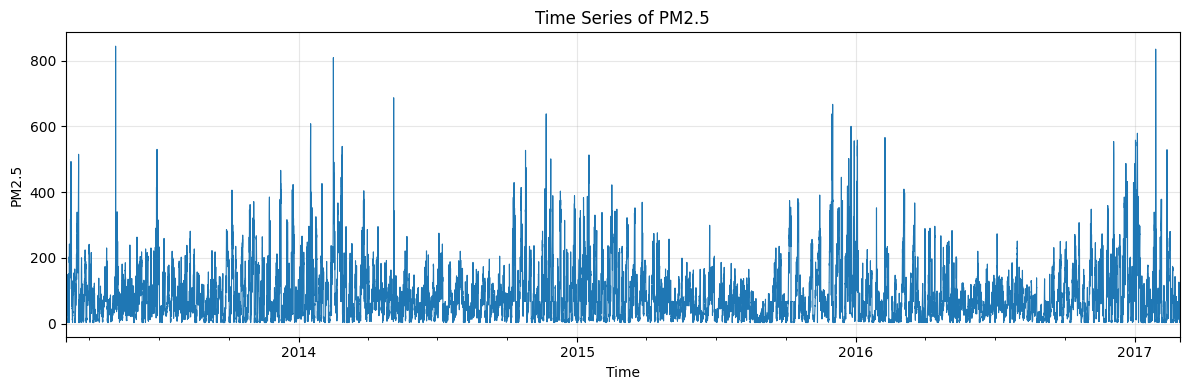

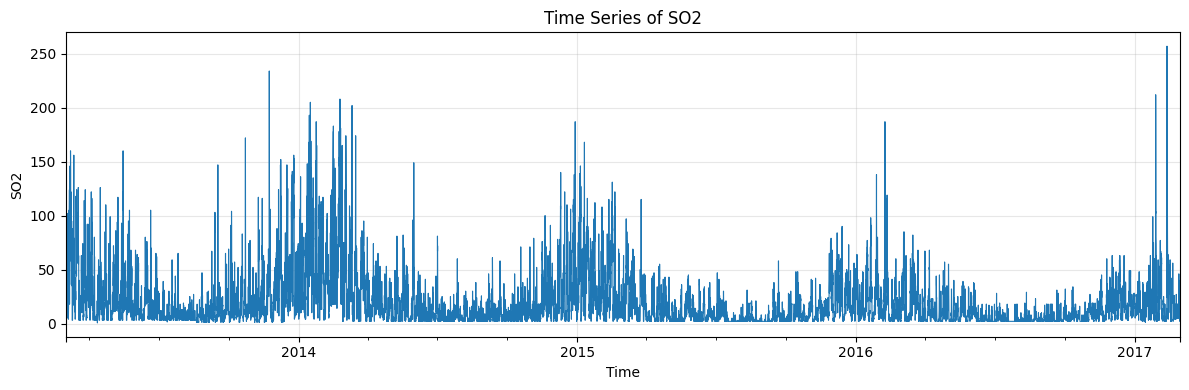

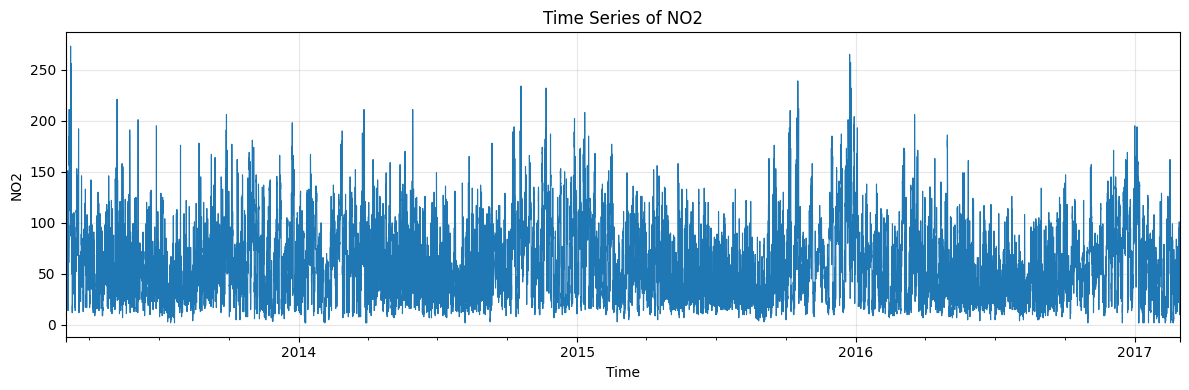

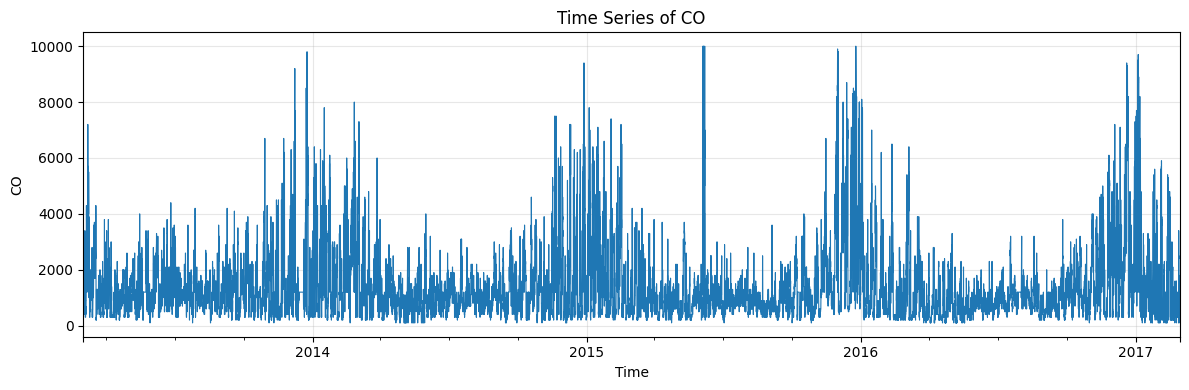

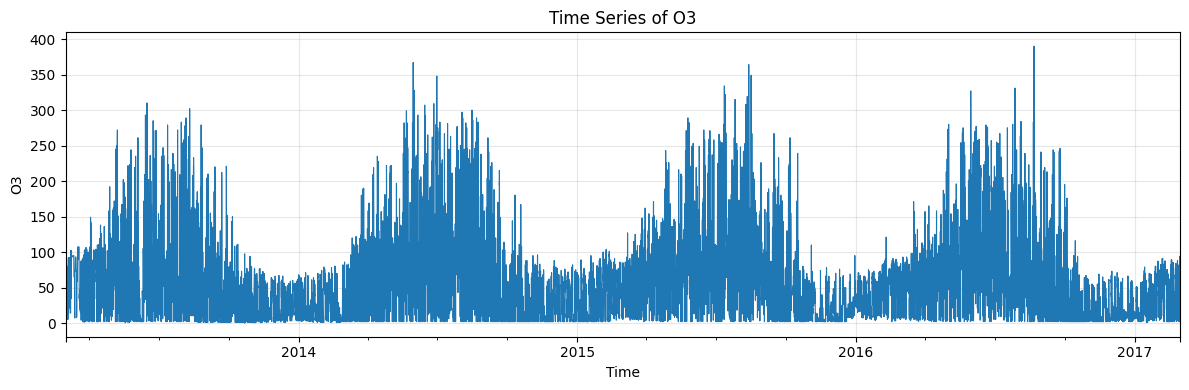

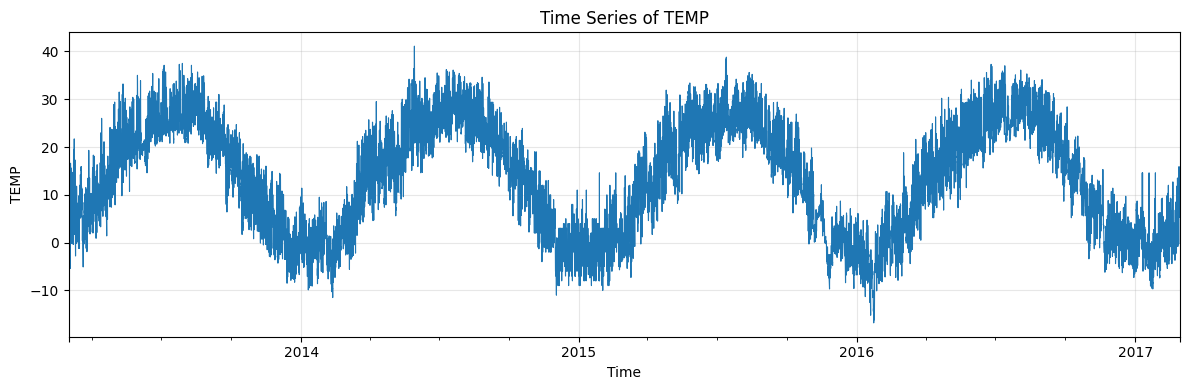

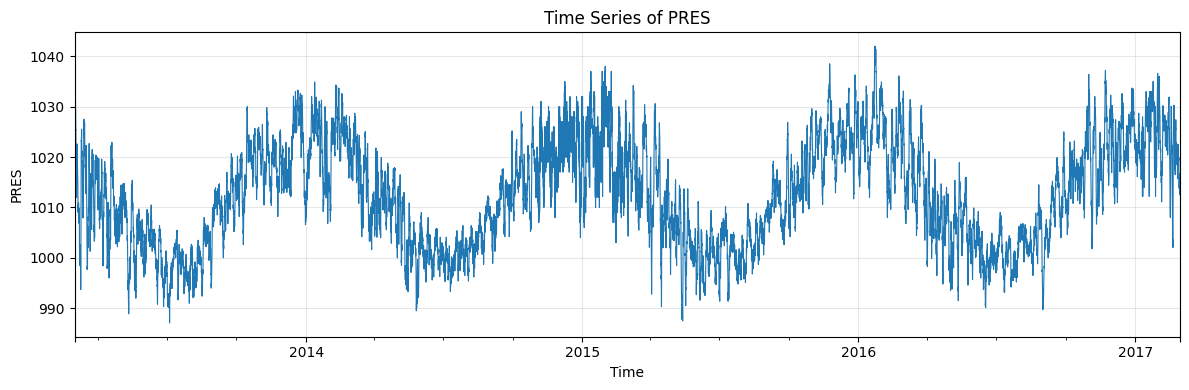

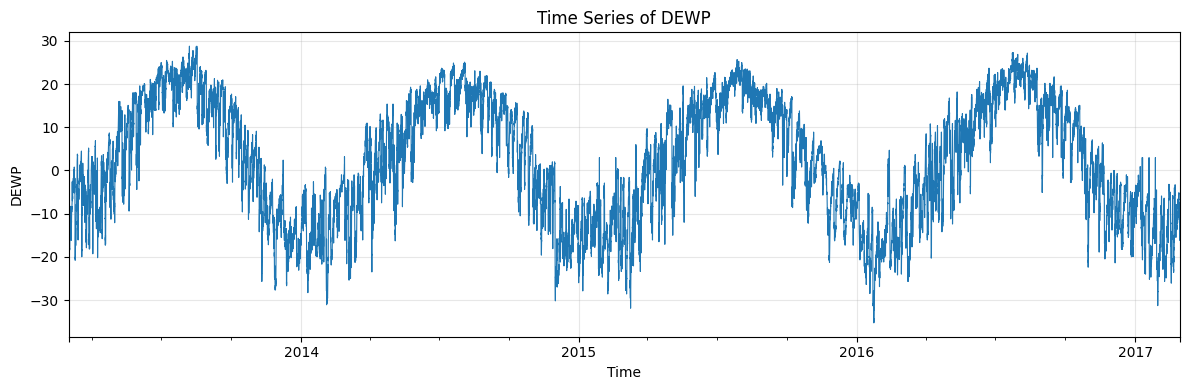

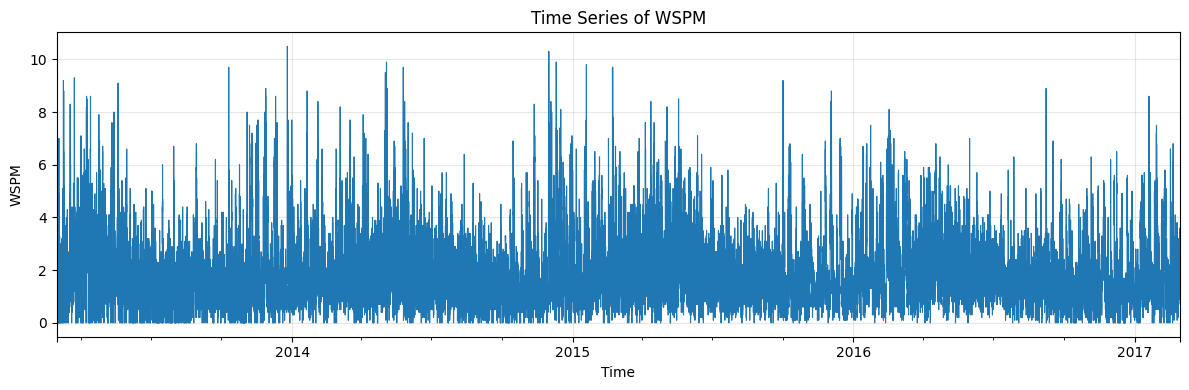

In [ ]:
import matplotlib.pyplot as plt

# Loop through all columns in your dataframe
for col in df.columns:
    plt.figure(figsize=(12,4))
    df[col].plot(lw=0.8)
    plt.title(f"Time Series of {col}")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

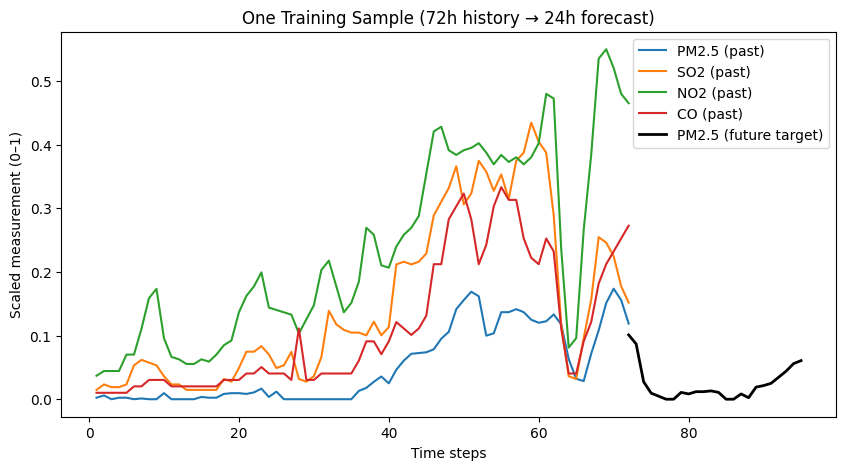

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_steps = LOOKBACK             # = 72 (input sequence length)
forecasting_horizon = HORIZON  # = 24 (output horizon)

plt.figure(figsize=(10,5))

# Plot first 4 input features (past 72h)
plt.plot(np.arange(1, n_steps+1, 1), X_train[0,:,0], label='PM2.5 (past)')
plt.plot(np.arange(1, n_steps+1, 1), X_train[0,:,1], label='SO2 (past)')
plt.plot(np.arange(1, n_steps+1, 1), X_train[0,:,2], label='NO2 (past)')
plt.plot(np.arange(1, n_steps+1, 1), X_train[0,:,3], label='CO (past)')

# Plot the target (next 24h PM2.5)
plt.plot(np.arange(n_steps, n_steps+forecasting_horizon, 1), y_train[0],
         label='PM2.5 (future target)', linewidth=2, color='black')

plt.title('One Training Sample (72h history → 24h forecast)')
plt.ylabel('Scaled measurement (0–1)')
plt.xlabel('Time steps')
plt.legend(loc='best')
plt.show()

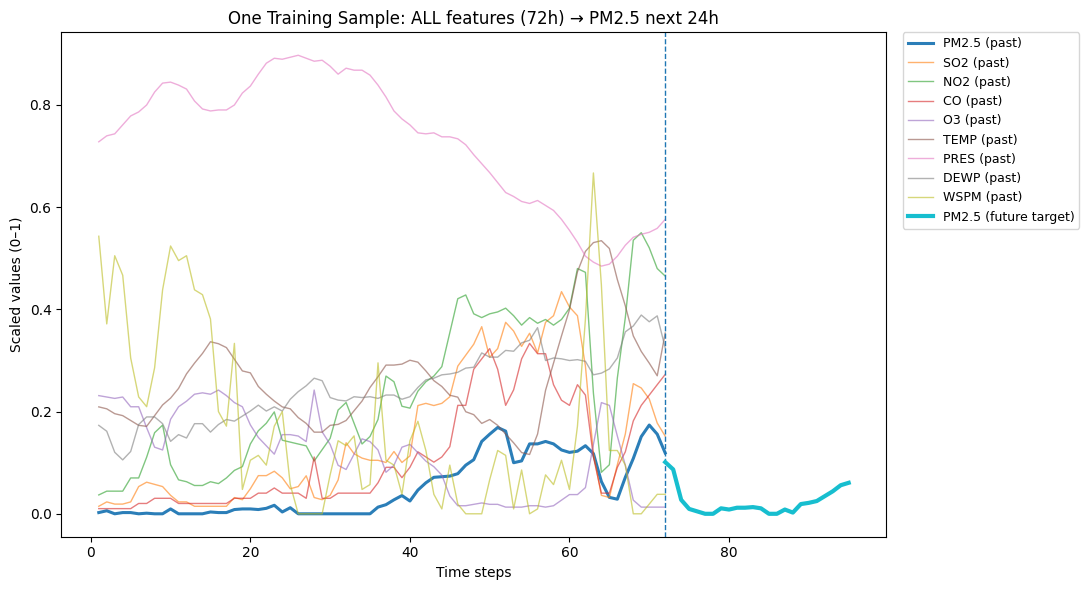

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sample_idx = 0
n_steps = LOOKBACK
h = HORIZON
feat_names = list(train_scaled.columns)

plt.figure(figsize=(11,6))

t_hist = np.arange(1, n_steps+1)
for j, name in enumerate(feat_names):
    lw = 2.2 if name == "PM2.5" else 1.0
    alpha = 0.95 if name == "PM2.5" else 0.6
    plt.plot(t_hist, X_train[sample_idx,:,j], linewidth=lw, alpha=alpha, label=f"{name} (past)")

plt.axvline(n_steps, linestyle="--", linewidth=1)

t_future = np.arange(n_steps, n_steps+h)
plt.plot(t_future, y_train[sample_idx], linewidth=3.0, label="PM2.5 (future target)")

plt.title("One Training Sample: ALL features (72h) → PM2.5 next 24h")
plt.xlabel("Time steps")
plt.ylabel("Scaled values (0–1)")
# put legend outside to avoid covering lines
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0., fontsize=9)
plt.tight_layout()
plt.show()

<a id = "cell_model"></a>
## 3. Predictive Modeling

*Create and explain your models (e.g., model architecture, model parameters). Evaluate the models on the experimental data sets.*

Final Model: 2-layer LSTM (128→64) with Dense head

We finalised a 2-layer LSTM model (128 → 64 units) with dropout and a dense head to predict a 24-hour horizon from 72 input steps and 9 features.
This structure captured both long- and short-term temporal patterns while controlling overfitting through dropout and recurrent dropout.
It achieved the best overall performance (RMSE ≈ 44.9, R² ≈ 0.305) across all 10 tested variations.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Shapes
n_steps  = X_train.shape[1]   # 72
features = X_train.shape[2]   # 9
HORIZON  = y_train.shape[1]   # 24

# 2-layer LSTM with dropout
model_lstm2 = Sequential([
    LSTM(128, activation="tanh", return_sequences=True, input_shape=(n_steps, features),
         dropout=0.2, recurrent_dropout=0.1),
    LSTM(64, activation="tanh", dropout=0.2, recurrent_dropout=0.1),
    Dense(64, activation="relu"),
    Dense(HORIZON)
])

model_lstm2.compile(optimizer="RMSprop", loss="mse")
model_lstm2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 128)        │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,784 (491.34 KB)

 Trainable params: 125,784 (491.34 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

# Helper to inverse-transform multi-horizon predictions
def inverse_horizon(y_arr, scaler):
    outs = []
    for h in range(y_arr.shape[1]):
        step = y_arr[:, h].reshape(-1, 1)
        outs.append(scaler.inverse_transform(step).ravel())
    return np.vstack(outs).T

# Predict (scaled → back to original PM2.5 units)
y_pred_gru2_scaled = model_lstm2.predict(X_test, verbose=0)
y_pred_gru2 = inverse_horizon(y_pred_gru2_scaled, target_scaler)
y_test_inv  = inverse_horizon(y_test,              target_scaler)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(monitor="loss", patience=8, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor="loss", factor=0.5, patience=4, min_lr=1e-5, verbose=1)

history_lstm2 = model_lstm2.fit(
    X_train, y_train,
    epochs=50, batch_size=32, verbose=1,
    callbacks=[es, rlr]
)

Epoch 1/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 196s 237ms/step - loss: 0.0090 - learning_rate: 0.0010
Epoch 2/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 183s 236ms/step - loss: 0.0076 - learning_rate: 0.0010
Epoch 3/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 200s 234ms/step - loss: 0.0073 - learning_rate: 0.0010
Epoch 4/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 203s 235ms/step - loss: 0.0072 - learning_rate: 0.0010
Epoch 5/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 203s 237ms/step - loss: 0.0070 - learning_rate: 0.0010
Epoch 6/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 183s 236ms/step - loss: 0.0069 - learning_rate: 0.0010
Epoch 7/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 203s 237ms/step - loss: 0.0068 - learning_rate: 0.0010
Epoch 8/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 185s 238ms/step - loss: 0.0068 - learning_rate: 0.0010
Epoch 9/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 201s 236ms/step - loss: 0.0067 - learning_rate: 0.0010
Epoch 10/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 183s 237ms/step - loss: 0.0066 - learning_rate: 0.0010
Epoch 11/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 201s 236

In [ ]:
y_pred_lstm2_scaled = model_lstm2.predict(X_test, verbose=0)
y_pred_lstm2 = inverse_horizon(y_pred_lstm2_scaled, target_scaler)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv.ravel(), y_pred_lstm2.ravel()))
mae  = mean_absolute_error(y_test_inv.ravel(), y_pred_lstm2.ravel())
r2   = r2_score(y_test_inv.ravel(), y_pred_lstm2.ravel())

print(f"LSTM-2L(128→64) — Test RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

LSTM-2L(128→64) — Test RMSE: 44.306 | MAE: 34.269 | R²: 0.323


In [ ]:
mae_by_h = [mean_absolute_error(y_test_inv[:, h], y_pred_lstm2[:, h]) for h in range(HORIZON)]
for h, v in enumerate(mae_by_h, start=1):
    print(f"Forecasting Horizon: +{h} hour  MAE: {v:.2f}")

Forecasting Horizon: +1 hour  MAE: 14.84
Forecasting Horizon: +2 hour  MAE: 18.67
Forecasting Horizon: +3 hour  MAE: 19.81
Forecasting Horizon: +4 hour  MAE: 23.44
Forecasting Horizon: +5 hour  MAE: 24.89
Forecasting Horizon: +6 hour  MAE: 27.55
Forecasting Horizon: +7 hour  MAE: 28.35
Forecasting Horizon: +8 hour  MAE: 31.30
Forecasting Horizon: +9 hour  MAE: 31.86
Forecasting Horizon: +10 hour  MAE: 31.96
Forecasting Horizon: +11 hour  MAE: 33.30
Forecasting Horizon: +12 hour  MAE: 34.97
Forecasting Horizon: +13 hour  MAE: 37.22
Forecasting Horizon: +14 hour  MAE: 37.79
Forecasting Horizon: +15 hour  MAE: 38.69
Forecasting Horizon: +16 hour  MAE: 39.84
Forecasting Horizon: +17 hour  MAE: 40.31
Forecasting Horizon: +18 hour  MAE: 42.02
Forecasting Horizon: +19 hour  MAE: 41.34
Forecasting Horizon: +20 hour  MAE: 43.66
Forecasting Horizon: +21 hour  MAE: 43.74
Forecasting Horizon: +22 hour  MAE: 44.71
Forecasting Horizon: +23 hour  MAE: 45.50
Forecasting Horizon: +24 hour  MAE: 46.66


In [ ]:
# --- Reshape test set for inverse transform ---
# Flatten from 3D [samples, timesteps, features] → 2D [samples*timesteps, features]
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])

# Inverse transform using the feature scaler (back to original units, e.g., PM2.5 µg/m³, °C, etc.)
X_test_inv = feature_scaler.inverse_transform(X_test_reshaped)

# Reshape back to 3D [samples, timesteps, features] for plotting/analysis
X_test_inv = X_test_inv.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

print("X_test_inv shape:", X_test_inv.shape)

X_test_inv shape: (649, 72, 9)


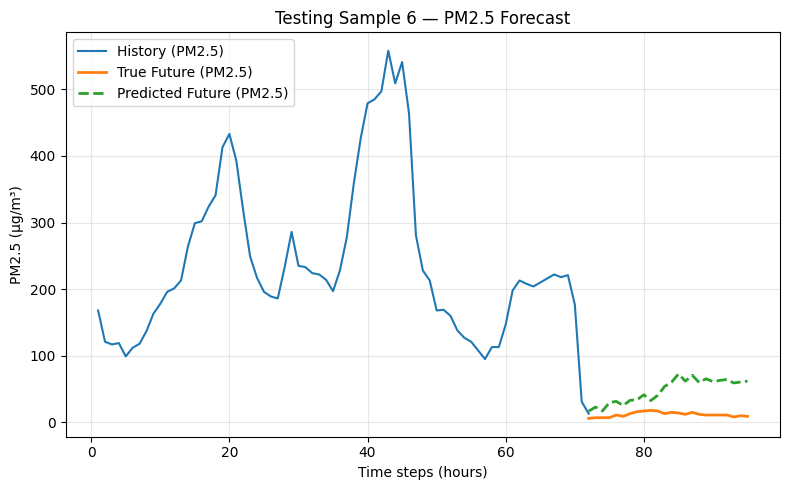

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a test sample to visualize (change index to explore different cases)
sample_index = 6   # or -1 for the last sample

plt.figure(figsize=(8, 5))

# --- Past 72h history (PM2.5 in original units) ---
plt.plot(np.arange(1, n_steps+1),
         X_test_inv[sample_index, :, all_cols.index("PM2.5")],
         label="History (PM2.5)")

# --- True next 24h ---
plt.plot(np.arange(n_steps, n_steps+HORIZON),
         y_test_inv[sample_index],
         label="True Future (PM2.5)", linewidth=2)

# --- Predicted next 24h ---
plt.plot(np.arange(n_steps, n_steps+HORIZON),
         y_pred_lstm2[sample_index],   # <- changed here
         label="Predicted Future (PM2.5)", linestyle="--", linewidth=2)

# Formatting
plt.title(f"Testing Sample {sample_index} — PM2.5 Forecast")
plt.xlabel("Time steps (hours)")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

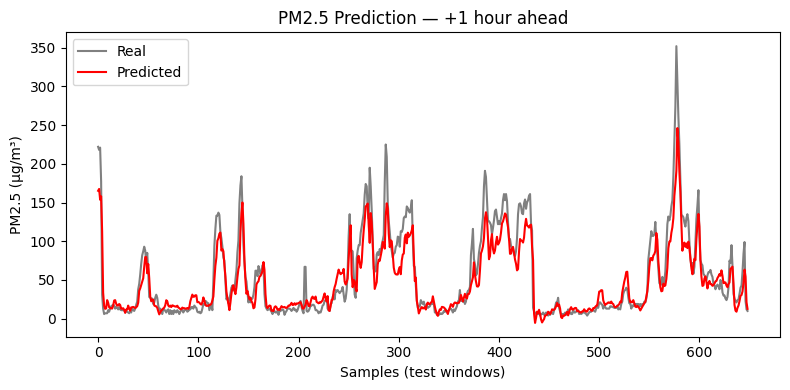

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(test, predicted, horizon_idx, title="PM2.5 Prediction"):
    plt.figure(figsize=(8,4))
    plt.plot(test, color="gray", label="Real")
    plt.plot(predicted, color="red", label="Predicted")
    plt.title(f"{title} — +{horizon_idx+1} hour ahead")
    plt.xlabel("Samples (test windows)")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example: visualize the 1-hour-ahead horizon
plot_predictions(y_test_inv[:, 0], y_pred_lstm2[:, 0], horizon_idx=0)

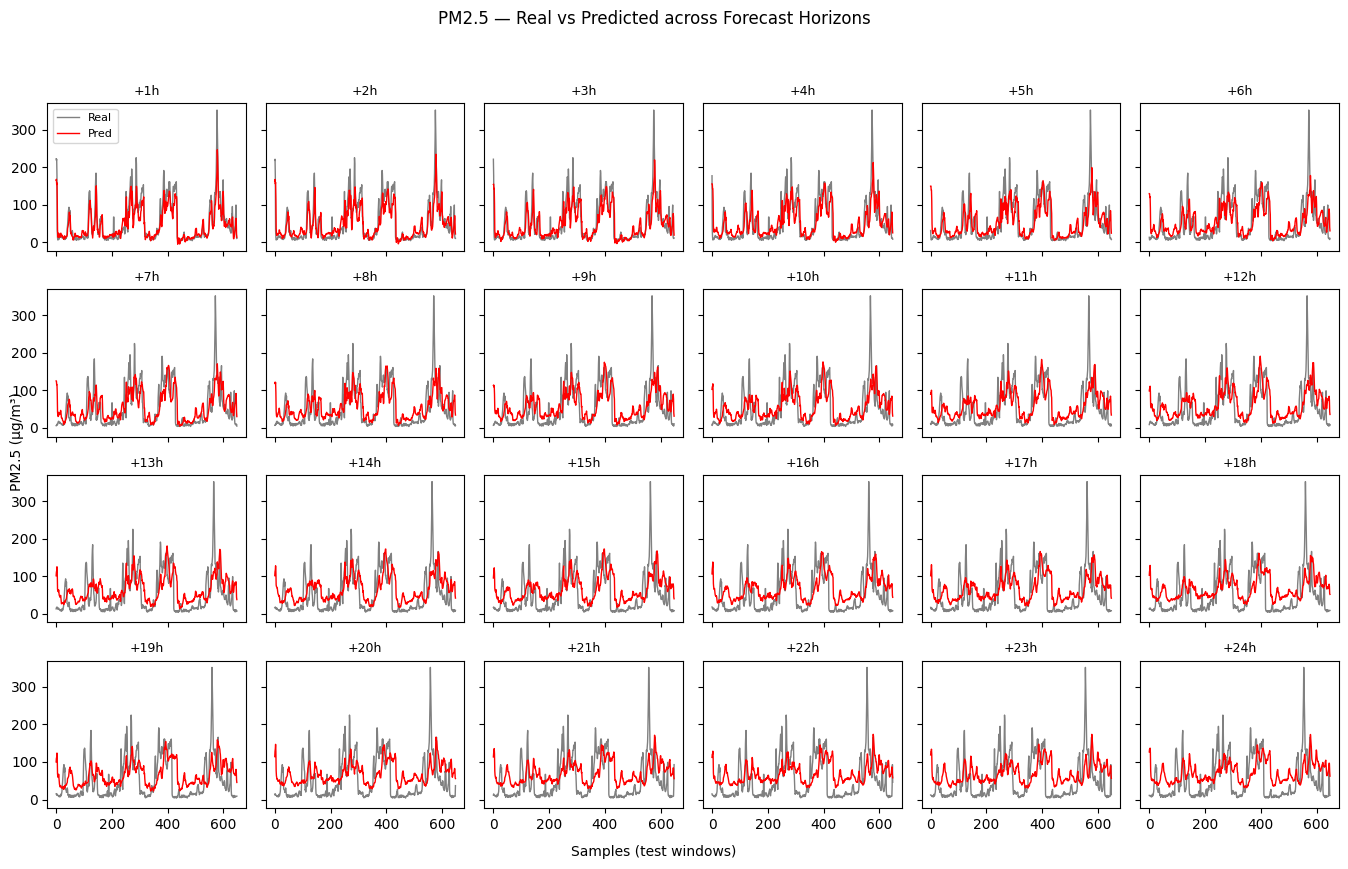

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 4 rows × 6 cols = 24 subplots
rows, cols = 4, 6
fig, axes = plt.subplots(rows, cols, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.ravel()

for h in range(HORIZON):  # HORIZON = 24
    ax = axes[h]
    ax.plot(y_test_inv[:, h], color="gray", linewidth=1, label="Real")
    ax.plot(y_pred_lstm2[:, h], color="red", linewidth=1, label="Pred")
    ax.set_title(f"+{h+1}h", fontsize=9)

# add legend only once
axes[0].legend(fontsize=8)

# overall title + axis labels
fig.suptitle("PM2.5 — Real vs Predicted across Forecast Horizons", fontsize=12)
fig.text(0.5, 0.04, "Samples (test windows)", ha="center")
fig.text(0.04, 0.5, "PM2.5 (µg/m³)", va="center", rotation="vertical")

plt.tight_layout(rect=[0.03, 0.05, 1, 0.95])
plt.show()

In [ ]:
#################################################################################################################################################################

<a id = "cell_report"></a>
## 4. Experiments Report

In [ ]:
from google.colab import files
from IPython.display import Image

In [ ]:
uploaded = files.upload()

Saving Task_3.png to Task_3.png


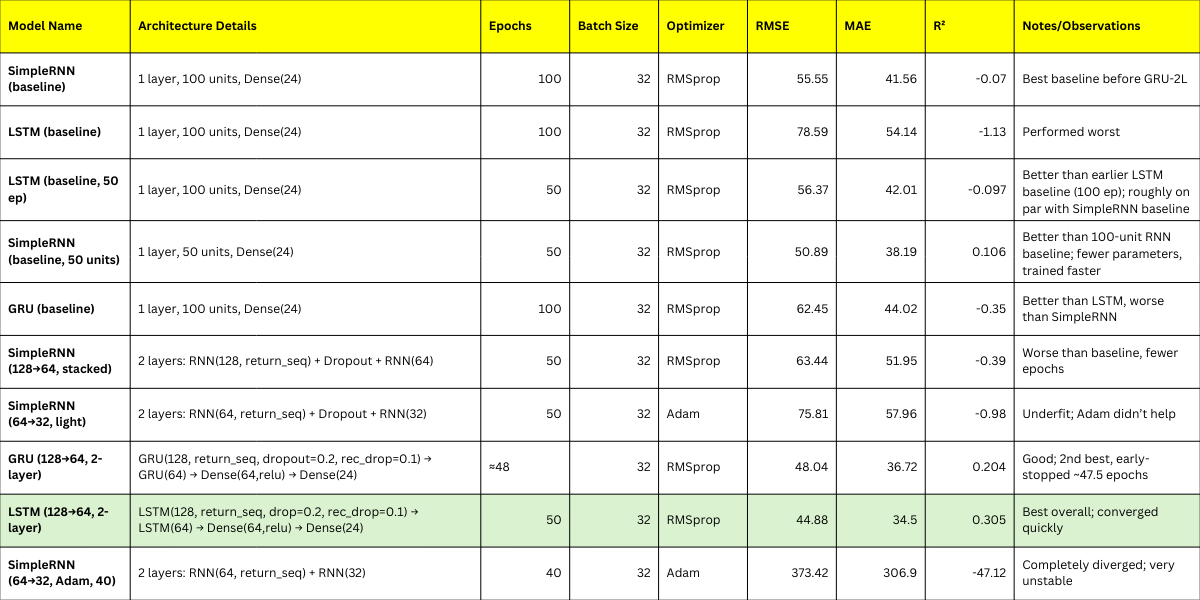

In [ ]:
Image('Task_3.png',
      width = 1200,
      height=600)



---


###**Flow of Models Tested**

We followed a structured and progressive approach to model building rather than running random architectures. The flow was:

1. **Baselines (single-layer models)**
- SimpleRNN (100 units) - served as the initial baseline for sequential modeling.
- LSTM (100 units) - tested for its ability to capture long-term dependencies.
- GRU (100 units) - evaluated as a more efficient alternative to LSTM.

2. **Reduced/Light Baselines**
- SimpleRNN (50 units) - fewer parameters to see if a lighter model performs better.
- LSTM (100 units, 50 epochs) - checked the impact of fewer training epochs.
3. **Deeper Architectures (Stacked)**
- SimpleRNN (128→64, stacked) - added depth with dropout for regularisation.
- SimpleRNN (64→32, Adam) - tested lighter stacked RNN with a different optimizer.
4. **Advanced Architectures with Regularisation**
- GRU (128→64, 2-layer) - added dropout, recurrent dropout, and a dense layer to improve generalisation.
- LSTM (128→64, 2-layer) - applied the same advanced design as GRU for direct comparison.

This flow ensured we compared baselines → lighter variants → deeper stacked models → regularised advanced models, which is systematic and avoids randomness.


---

###**Key Insights**

**Baselines:**

- The SimpleRNN baseline outperformed LSTM and GRU single-layer baselines, showing that for this dataset, simpler models can capture short-term dependencies effectively.
- The LSTM baseline performed worst, likely due to overfitting and poor convergence with limited data.

**Light/Reduced Baselines:**

- Reducing SimpleRNN to 50 units improved results (lower RMSE/MAE), confirming that fewer parameters reduce overfitting and make the model more efficient.

**Stacked Architectures:**

- Adding extra layers to SimpleRNN did not help; the stacked model increased error due to overfitting and unstable training.

**Advanced Architectures:**
- GRU (128→64, 2-layer) gave a strong improvement, achieving RMSE ≈ 48.0. GRUs balanced performance and training time.
- LSTM (128→64, 2-layer) was the best performer overall with RMSE ≈ 44.9, MAE ≈ 34.5, and R² ≈ 0.31. Adding dropout and recurrent dropout improved generalisation and convergence speed.



---


###**Best Model Explanation**

The LSTM (128→64, 2-layer) achieved the best performance because:
- It balances depth and regularisation: two LSTM layers capture both short and long-term dependencies.
- Dropout + recurrent dropout prevent overfitting.
- A Dense(64, relu) layer before the output adds nonlinearity to map hidden states to forecast horizons.
- It converged quickly within 50 epochs, showing stable and efficient training.



---


###**Business Problem Connection**
- **Problem:** Forecast PM2.5 for the next 24 hours to support early-warning systems for air pollution in Beijing.
How solution helps:
- The chosen LSTM model gives reasonably accurate forecasts for short horizons (1–6 hours), where MAE is low.
- This allows proactive responses (e.g., traffic regulation, alerts for sensitive groups, factory shutdown schedules).


---



###**Considerations for Real-world Deployment**
1. Decreasing accuracy with horizon: Errors grow after +12 hours. Model is reliable for short-term forecasts, but planners should be cautious with forecasts beyond 12–24 hours.
2. Data pipeline: The model needs clean, continuous hourly data with preprocessing (imputation + scaling). Missing or corrupted data could degrade forecasts.
3. Retraining: Air pollution dynamics change with seasonality and policies. Regular retraining with fresh data is required.
4. Integration: Forecasts should be integrated into dashboards or alert systems with visualizations for policymakers and citizens.
5. Computational efficiency: The 2-layer LSTM is relatively light, so it can run in near real-time on modest hardware.


---




<a id = "cell_report"></a>
## 5. Role of GenAI


Generative AI tools such as ChatGPT were utilised throughout the development of the forecasting models as a collaborative assistant. GenAI supported the workflow in several ways:

- **Code troubleshooting:** Helped identify and resolve coding errors (e.g., fixing interpolation methods, handling missing values, and adjusting TensorFlow/Keras layer parameters).
- **Model experimentation:** Suggested alternative architectures (e.g., variations of SimpleRNN, GRU, and LSTM with different units, layers, and optimisers), enabling systematic benchmarking.

- **Report drafting:** Assisted in explaining technical steps in plain language and aligning code outputs with business interpretations for clearer documentation.

Critically, while GenAI accelerated iteration and reduced debugging time, it was not without challenges. Responses occasionally required verification, as some suggestions were generic, context-blind, or incompatible with the dataset. This necessitated continuous cross-checking with TensorFlow documentation and experimental validation.

Overall, GenAI served best as a co-pilot valuable for ideation, experimentation, and error resolution—yet dependent on human oversight to ensure correctness, relevance, and business alignment.